
# Investigating `bbhx`'s time-windowing kwargs (`t_ref`, `t_obs_start`, `t_obs_end`, `shift_t_limits`)

**Question that motivated this:** can we get `BBHWaveformFD` to directly generate only a 2-month
slice of data starting 6 months into the observation (e.g. `t_obs_start=6/12`, `t_obs_end=8/12`),
instead of always generating the full `Tobs` window used elsewhere in this project?

**Short answer: no, not with this version of `bbhx` (1.2.3) -- passing a nonzero `t_obs_start`
silently zeroes out the whole waveform.** This is a real inconsistency in the installed package,
not a usage mistake. The correct, robust way to get a mid-observation slice is to generate the
full-duration waveform (as the rest of this project already does) and slice the **time-domain**
signal afterward -- demonstrated and verified below.

Everything here was worked out by reading the actual `bbhx` source (not just its docstrings),
found at:

```
.venv/lib/python3.12/site-packages/bbhx/waveformbuild.py        (Python: BBHWaveformFD.__call__)
.venv/lib/python3.12/site-packages/bbhx/waveforms/phenomhm.py   (Python: PhenomHMAmpPhase.__call__)
~/.cache/uv/git-v0/checkouts/.../src/bbhx/cutils/WaveformBuild.cu  (CUDA/C++: the actual TDI fill kernel)
```

No files in this repo or in `bbhx` were modified to produce this notebook.



## What each kwarg actually does (from reading the source, not the docstrings)

**`t_ref`** -- the absolute time, in seconds, on the *same clock* that `t_obs_start`/`t_obs_end`
are measured on, at which the waveform's frequency equals `f_ref` (merger time, roughly, for
`f_ref=0`). Mechanically: `PhenomHMAmpPhase` first builds the whole time-frequency track `tf(f)`
with the merger internally pinned at `tf=0`, then literally adds `t_ref` to every entry of that
array (`phenomhm.py` lines ~501-507: `self.waveform_carrier[2*n:3*n] += tile(t_ref, ...)`). So
`t_ref` is nothing but a shift that repositions the whole `tf` track on the absolute timeline --
it's "where in the observation does the merger land."

**`t_obs_start` / `t_obs_end`** -- meant to be the observation window's start/end, in years,
"with reference to t=0" (i.e. the same absolute clock `t_ref` lives on). They get converted to
seconds and then run through `tSSBfromLframe` (`waveformbuild.py` lines 468-475), which nudges
them by up to ~500 seconds depending on `lam`/`beta` -- LISA's barycenter is offset from the Sun by
1 AU, so "start of observation at the LISA constellation" isn't quite the same instant as "start of
observation at the solar-system barycenter," and that correction depends on where on the sky the
source is. After that they're used in **two different, inconsistent ways**:

1. As `Tobs = t_end - t_start`, fed into `PhenomHMAmpPhase` (`waveformbuild.py` line 515), which
   uses it to decide which part of the frequency track is "in band": it keeps only frequencies
   where `0 <= tf <= Tobs` (`phenomhm.py` lines 520, 571) -- **always measured from absolute
   zero**, never from `t_start`. This is the bug: it should be checking `t_start <= tf <= t_end`,
   but it only ever gets handed the duration.
2. As the true `t_start`/`t_end` passed all the way down to the compiled response/interpolation
   code, where they're used *correctly* to mask the final output: `WaveformBuild.cu`'s
   `combine_information` (line 50) does exactly `tf >= t_start && (tf <= t_end || t_end <= 0)`.

Because step 1 runs first and already throws away everything outside `[0, t_end - t_start]`, step
2's correct mask has nothing left to work with whenever `t_start` is not ~0 and the true signal
(anchored near `t_ref`) doesn't happen to also live inside `[0, t_end - t_start]`. This is confirmed
experimentally below.

**`shift_t_limits`** -- dead code in this installed version (1.2.3). There used to be a
`shift_t_limits=False` mode that measured `t_obs_start`/`t_obs_end` backwards from `t_ref` instead
of forwards from `t=0`; that branch is now commented out and the code unconditionally runs the
`shift_t_limits=True` path regardless of what you pass. Passing `False` only raises a
`DeprecationWarning` and otherwise changes nothing -- verified below. Leave it at the default.



## Setup

Reuses `simulator.py`'s exact waveform generator (`sim.wave_gen`), frequency grid, and STFT
settings, so this stays consistent with the rest of the project. One fixed set of source
parameters is used throughout (masses/spins/distance from `config.yaml`'s fixed values, arbitrary
but fixed sky position/orientation) -- only the time-windowing kwargs change between experiments.


In [1]:
import warnings

import numpy as np
import torch
import matplotlib.pyplot as plt

import simulator as sim
from priors import FIXED_PARAMS
from lisatools.utils.constants import YRSID_SI

DAY_SI = 24 * 3600
MONTH_SI = 30.45428241 * DAY_SI

# fixed source parameters for every experiment below -- only t_ref/t_obs_start/t_obs_end vary
SOURCE_KWARGS = dict(
    m1=np.array([2e5]), m2=np.array([1e5]), chi1z=np.array([0.0]), chi2z=np.array([0.7]),
    distance=np.array([FIXED_PARAMS["dist"]]),
    phi_ref=np.array([1.0]), f_ref=np.array([0.0]),
    inc=np.array([1.0]), lam=np.array([1.0]), beta=np.array([0.3]), psi=np.array([0.5]),
)


def generate(t_ref, t_obs_start, t_obs_end, **extra):
    return sim.wave_gen(
        **SOURCE_KWARGS,
        t_ref=np.array([t_ref]),
        t_obs_start=t_obs_start,
        t_obs_end=t_obs_end,
        freqs=sim.freq,
        modes=sim.MODES,
        direct=False,
        length=1024,
        squeeze=False,
        compress=True,
        fill=True,
        combine=False,
        **extra,
    )


print(f"project's default t_ref (T_C) = {sim.T_C:.4e} s = {sim.T_C / MONTH_SI:.3f} months into the year")
print(f"full observation Tobs = {sim.Tobs:.4e} s = {sim.Tobs / YRSID_SI:.3f} yr, dt={sim.dt}s, N={sim.N}")

No CuPy
project's default t_ref (T_C) = 3.1126e+07 s = 11.829 months into the year
full observation Tobs = 3.1558e+07 s = 1.000 yr, dt=5.0s, N=6311629



## Step 1 -- reproduce the failure

This is exactly the naive thing that seems like it should work: `t_obs_start=6/12`,
`t_obs_end=8/12` (years), i.e. "generate the 6th-to-8th month of the observation." Tried twice --
once with the merger (`t_ref`) left at its usual place near the end of the year, once with the
merger moved to sit *inside* the requested window (7 months) so it isn't a merger-location
coincidence.


In [2]:
def report(label, out):
    nonzero = np.count_nonzero(out)
    print(f"{label}: nonzero {nonzero}/{out.size} ({100 * nonzero / out.size:.4f}%), "
          f"max|.|={np.abs(out).max():.3e}")


report("A. full year (t_obs=[0,1], t_ref at default ~11.8mo)", generate(sim.T_C, 0.0, 1.0))

report("B. naive 6-8mo window, t_ref left at default ~11.8mo",
       generate(sim.T_C, 6 / 12, 8 / 12))

report("C. naive 6-8mo window, t_ref moved INSIDE the window (7mo)",
       generate(7 * MONTH_SI, 6 / 12, 8 / 12))

A. full year (t_obs=[0,1], t_ref at default ~11.8mo): nonzero 9460047/9467445 (99.9219%), max|.|=6.242e-18
B. naive 6-8mo window, t_ref left at default ~11.8mo: nonzero 0/9467445 (0.0000%), max|.|=0.000e+00
C. naive 6-8mo window, t_ref moved INSIDE the window (7mo): nonzero 0/9467445 (0.0000%), max|.|=0.000e+00



Both B and C come back **completely empty** (0 nonzero entries) even though C's merger is
squarely inside the requested window -- confirming this isn't a "wrong part of the signal" issue,
the output is genuinely all zeros.

The next two cases isolate why: `t_obs_start=0` (matching the pre-filter's zero-anchored
assumption from step 1 of the explanation above) with a truncated `t_obs_end` **does** produce
nonzero output, at the point in [0, t_obs_end] where the signal is expected to actually reach:


In [3]:
report("D. t_obs_start=0, t_obs_end=8mo, t_ref inside window (7mo) -- expect nonzero",
       generate(7 * MONTH_SI, 0.0, 8 / 12))

report("E. t_obs_start=0, t_obs_end=6mo, t_ref AFTER the window (7mo) -- expect ~zero",
       generate(7 * MONTH_SI, 0.0, 6 / 12))

D. t_obs_start=0, t_obs_end=8mo, t_ref inside window (7mo) -- expect nonzero: nonzero 9458433/9467445 (99.9048%), max|.|=1.041e-17
E. t_obs_start=0, t_obs_end=6mo, t_ref AFTER the window (7mo) -- expect ~zero: nonzero 65805/9467445 (0.6951%), max|.|=5.029e-19



D confirms the diagnosis precisely: with `t_obs_start=0`, the buggy zero-anchored pre-filter and
the correct `[t_start, t_end]` mask agree (both windows start at 0), so essentially the whole
inspiral-to-merger track survives (99.9% nonzero, same order as the full-year case A). E flips it
around -- the window ends a month *before* the merger, so only the correspondingly small sliver of
early inspiral whose `tf` happens to fall before 6 months survives (0.70% nonzero, two orders of
magnitude less than D) -- exactly the expected behavior for a window that stops short of the
signal's most frequency-dense (near-merger) part, not the "everything or nothing" pattern from B/C.
**The takeaway: only `t_obs_end` (with `t_obs_start` left at its default `0.0`) behaves as
documented in this bbhx version. Any nonzero `t_obs_start` is currently broken.**

## Confirming `shift_t_limits` is dead code

Generate the same waveform with `shift_t_limits=True` (default) and `shift_t_limits=False`, and
diff the outputs.


In [4]:
out_true = generate(sim.T_C, 0.0, 1.0, shift_t_limits=True)
with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")
    out_false = generate(sim.T_C, 0.0, 1.0, shift_t_limits=False)

print("warning raised for shift_t_limits=False:", [str(w.message) for w in caught])
print("output identical to shift_t_limits=True:", np.array_equal(out_true, out_false))

warning raised for shift_t_limits=False: ['Deprecated: shift_t_limits. Previously shift_t_limits defaulted to False. This option is now removed and permanently set to shift_t_limits=True.']
output identical to shift_t_limits=True: True



## The correct approach: generate the full observation, slice in the time domain

Generate the full `[0, 1yr]` waveform exactly as `simulator.py` already does elsewhere in this
project, `irfft` it to the time domain, then just index the 6-8 month range out of the resulting
array. This sidesteps `bbhx`'s broken `t_obs_start` handling entirely, because we never ask it for
anything other than the one window (`[0, 1yr]`) it actually gets right.

For this to produce an interesting plot (rather than a quiet stretch of inspiral), `t_ref` is
placed at 7 months so the window contains the merger and its antenna-pattern nulls.


sliced window: [5.9926, 7.9956] months, 1054080 samples


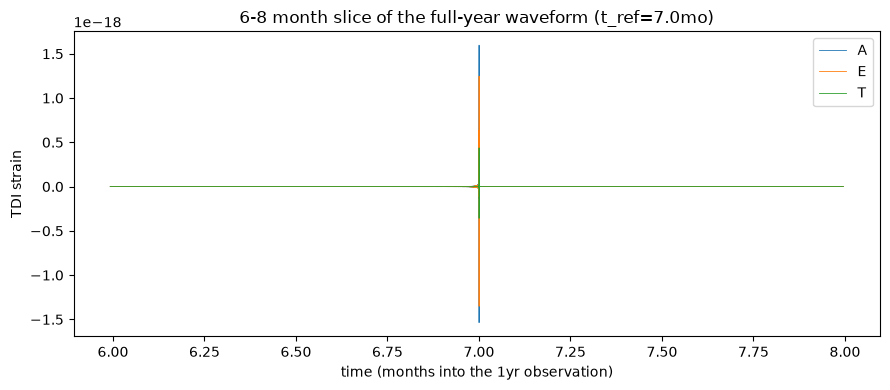

In [5]:
t_ref_demo = 7 * MONTH_SI

wave_freq_full = generate(t_ref_demo, 0.0, 1.0)
wave_time_full = sim.waveforms_to_time_domain(wave_freq_full, device="cpu")  # (1, 3, N)

t_full = np.arange(sim.N) * sim.dt

# align the slice to the STFT hop grid (see the verification step below for why this matters)
raw_i0 = int(round(6 * MONTH_SI / sim.dt))
raw_i1 = int(round(8 * MONTH_SI / sim.dt))
i0 = (raw_i0 // sim.HOP_LENGTH) * sim.HOP_LENGTH
i1 = (raw_i1 // sim.HOP_LENGTH) * sim.HOP_LENGTH

sliced_time = wave_time_full[:, :, i0:i1]
print(f"sliced window: [{i0 * sim.dt / MONTH_SI:.4f}, {i1 * sim.dt / MONTH_SI:.4f}] months, "
      f"{sliced_time.shape[-1]} samples")

fig, ax = plt.subplots(figsize=(9, 4))
t_slice_months = np.arange(i0, i1) * sim.dt / MONTH_SI
for ch, label in enumerate(["A", "E", "T"]):
    ax.plot(t_slice_months, sliced_time[0, ch].numpy(), label=label, linewidth=0.6)
ax.set_xlabel("time (months into the 1yr observation)")
ax.set_ylabel("TDI strain")
ax.set_title(f"6-8 month slice of the full-year waveform (t_ref={t_ref_demo / MONTH_SI:.1f}mo)")
ax.legend()
fig.tight_layout()
plt.show()


## Verifying the slice is correct

The check: take the per-time-bin STFT envelope (same recipe as `simulator.compute_bumps`) computed
on the **full** year, and pick out just the bins that fall in `[6, 8]` months. Separately, compute
the STFT envelope directly on the **already-sliced** 2-month array from the cell above. If slicing
in the time domain is valid, these two should agree almost exactly in the interior (away from the
slice edges, where `torch.stft`'s `center=True` zero-padding has no way to know about data outside
the slice).

This also demonstrates why the slice above was aligned to `sim.HOP_LENGTH`: if the slice boundary
isn't a multiple of the STFT hop length, the two time-bin grids are offset from each other by a
fraction of a bin and this comparison isn't apples-to-apples.


comparing 122 STFT time bins
median relative difference (all bins):      0.000e+00
median relative difference (interior bins):  0.000e+00
max relative difference at the two edges:     1.850e-01


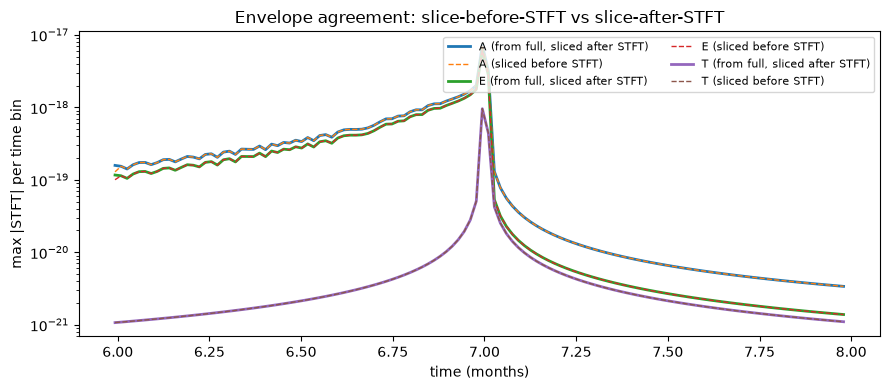

In [6]:
def stft_magnitude(x):
    n_time = x.shape[-1]
    window = sim.STFT_WINDOW.to(dtype=x.dtype)
    zxx = torch.stft(
        x.reshape(-1, n_time), n_fft=sim.NPERSEG, hop_length=sim.HOP_LENGTH,
        win_length=sim.NPERSEG, window=window, center=True, onesided=True, return_complex=True,
    )
    return zxx.abs()  # (batch*channels, n_freq, n_time_bins)


# envelope from the full year, restricted to bins inside [6, 8] months
full_stft = stft_magnitude(wave_time_full)
t_bins_full = np.arange(full_stft.shape[-1]) * sim.HOP_LENGTH * sim.dt
bin_mask = (t_bins_full >= i0 * sim.dt) & (t_bins_full < i1 * sim.dt)
env_from_full = full_stft.amax(dim=-2)[:, bin_mask]

# envelope computed directly on the pre-sliced 2-month array
sliced_stft = stft_magnitude(sliced_time)
env_from_slice = sliced_stft.amax(dim=-2)

n_compare = min(env_from_full.shape[-1], env_from_slice.shape[-1])
a = env_from_full[..., :n_compare].numpy()
b = env_from_slice[..., :n_compare].numpy()
rel_diff = np.abs(a - b) / (np.abs(a) + 1e-300)

print(f"comparing {n_compare} STFT time bins")
print(f"median relative difference (all bins):      {np.median(rel_diff):.3e}")
print(f"median relative difference (interior bins):  {np.median(rel_diff[..., 2:-2]):.3e}")
print(f"max relative difference at the two edges:     {max(rel_diff[..., :2].max(), rel_diff[..., -2:].max()):.3e}")

fig, ax = plt.subplots(figsize=(9, 4))
t_bins_compare = t_bins_full[bin_mask][:n_compare] / MONTH_SI
for ch, label in enumerate(["A", "E", "T"]):
    ax.plot(t_bins_compare, a[ch], label=f"{label} (from full, sliced after STFT)", linewidth=2)
    ax.plot(t_bins_compare, b[ch], "--", label=f"{label} (sliced before STFT)", linewidth=1)
ax.set_yscale("log")
ax.set_xlabel("time (months)")
ax.set_ylabel("max |STFT| per time bin")
ax.set_title("Envelope agreement: slice-before-STFT vs slice-after-STFT")
ax.legend(fontsize=8, ncol=2)
fig.tight_layout()
plt.show()


## Summary

- `t_ref` positions the merger on the absolute observation timeline; `t_obs_start`/`t_obs_end`
  are supposed to bound that timeline in years but, in installed `bbhx` 1.2.3, only `t_obs_end`
  (with `t_obs_start` left at `0.0`) actually works -- any nonzero `t_obs_start` makes
  `BBHWaveformFD` return an all-zero waveform, because of a mismatch between a Python-level
  pre-filter (anchored at absolute `t=0`) and the correct C++-level `[t_start, t_end]` mask.
  `shift_t_limits` has no effect at all besides a deprecation warning.
- **Recommendation:** don't fight `bbhx`'s windowing for sub-observation slices. Generate the
  full `[0, 1yr]` waveform (as `simulator.py` already does), and slice the resulting time-domain
  array to whatever window you want. Verified above: this gives bin-for-bin identical STFT
  envelopes to computing the STFT directly on that slice, as long as the slice boundaries are
  aligned to the STFT hop grid (`sim.HOP_LENGTH`) -- the only difference is the expected
  window-edge effect at the very first/last bin, where `center=True` padding has no way to see
  data beyond the slice.
